# Deep Belief Networks

---

### Sau notebook này, bạn sẽ có thể:

| # | Mục tiêu | Đánh giá bằng |
|---|----------|---------------|
| 1 | Giải thích cấu trúc của DBN: RBM là gì, chúng xếp chồng như thế nào | Vẽ được kiến trúc DBN và mô tả vai trò từng tầng |
| 2 | Mô tả cách DBN học từ dữ liệu: Contrastive Divergence, Greedy Pre-training | Giải thích được quá trình positive/negative phase |
| 3 | So sánh DBN và CNN: điểm mạnh, điểm yếu, khi nào dùng cái nào | Chọn đúng mô hình cho một bài toán cụ thể |

---

### Nội dung

```
Phần 1 — DBN là gì?          Cái nhìn tổng quan trước khi đi vào chi tiết
   │
Phần 2 — Khối xây dựng: RBM  Cấu trúc, hàm năng lượng, xác suất, Contrastive Divergence
   │
Phần 3 — Từ RBM đến DBN      Xếp chồng, Greedy Pre-training, Fine-tuning
   │
Phần 4 — Thực hành MNIST     Train, Reconstruction, Generation, Fine-tuning
   │
Phần 5 — DBN vs CNN           So sánh kiến trúc và triết lý học
   │
Phần 6 — Tổng kết
```


# Phần 1: DBN là gì?

---

Trước khi đi vào toán học, ta cần có bức tranh toàn cảnh. **Deep Belief Network** là một mô hình học sâu được tạo thành bằng cách **xếp chồng nhiều lớp Restricted Boltzmann Machine (RBM)** lên nhau.

<img src="https://miro.medium.com/v2/1*tX0X2_PLDh9oIZDkN4mTtQ.jpeg" width="500">

Một DBN điển hình cho bài toán nhận dạng chữ số MNIST có kiến trúc:

$$\text{Ảnh (784 pixel)} \xrightarrow{\text{RBM}_1} \text{512 đặc trưng} \xrightarrow{\text{RBM}_2} \text{256 đặc trưng} \xrightarrow{\text{RBM}_3} \text{128 đặc trưng}$$

Mỗi tầng học một mức **trừu tượng hóa cao hơn**:
- **Tầng 1**: học các đường nét, cạnh cơ bản từ pixel thô
- **Tầng 2**: học cách các nét ghép thành vòng, góc, nhánh
- **Tầng 3**: học cách các thành phần tạo thành chữ số hoàn chỉnh

### Điều gì làm DBN đặc biệt?

DBN có **ba điểm khác biệt** so với mạng neural thông thường:

**1. Học không giám sát (Unsupervised)** — DBN học cấu trúc của dữ liệu mà không cần nhãn. Không ai nói cho nó biết "đây là số 3" — nó tự tìm ra các mẫu thống kê trong dữ liệu.

**2. Học từng lớp một (Greedy Layer-wise)** — Thay vì train toàn bộ mạng cùng lúc (dễ bị vanishing gradient), DBN train từng RBM riêng biệt, tầng thấp trước, tầng cao sau.

**3. Vừa phân tích vừa sinh tạo (Generative)** — DBN không chỉ nhận dạng dữ liệu, nó còn có thể **tạo ra** dữ liệu mới trông giống thật — điều mà CNN thông thường không làm được.

---

### Tóm tắt luồng hoạt động

```
[Dữ liệu thô] → RBM₁ → RBM₂ → RBM₃ → [Biểu diễn ẩn]
                                              ↓
                                     + Thêm lớp phân loại
                                              ↓
                                     Fine-tune với nhãn
                                              ↓
                                     [Nhãn dự đoán]
```

Bây giờ ta sẽ xây dựng từng mảnh của bức tranh này từ nền tảng.


# Phần 2: Restricted Boltzmann Machine — Khối xây dựng cơ bản

---

RBM là **đơn vị cấu thành** của DBN. Hiểu RBM là hiểu mọi thứ. Phần này sẽ đi từ cấu trúc → toán học → code theo từng bước nhỏ.

> **Trước tiên**, ta import các thư viện cần thiết cho toàn bộ notebook:


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)


---

## 1.1  Dữ liệu đi vào mạng như thế nào?

Hãy bắt đầu từ thứ cụ thể nhất có thể: một tấm ảnh chữ số từ bộ MNIST. Mỗi ảnh có kích thước **28 × 28 pixel**, mỗi pixel là một số thực trong khoảng [0, 1] — giá trị 0 nghĩa là trắng hoàn toàn, giá trị 1 nghĩa là đen hoàn toàn.

Trước khi đưa vào mạng, tấm ảnh 2 chiều này được trải phẳng (flatten) thành một vector 1 chiều dài **784 phần tử**. Vector 784 chiều này chính là **input** của mạng. Và lớp đầu tiên của RBM được thiết kế để nhận đúng vector đó.

---

## 1.2  Visible Layer và Hidden Layer: Tại sao lại đặt tên như vậy?

RBM có hai tầng. Tầng thứ nhất gọi là **visible layer**, đây là tầng chứa dữ liệu *có thể quan sát được*. Nếu đang làm việc với ảnh MNIST, visible layer chứa 784 neuron, mỗi neuron tương ứng với giá trị của một pixel. Nếu làm việc với âm thanh, visible layer chứa các mẫu âm thanh. Nếu làm việc với dữ liệu y tế, visible layer chứa các chỉ số xét nghiệm.

Tầng thứ hai gọi là **hidden layer**, đây là tầng chứa những thứ *không thể quan sát trực tiếp*. Không có dữ liệu nào trong tập huấn luyện cho bạn biết mỗi hidden neuron nên có giá trị bao nhiêu. Những giá trị đó được mô hình **tự tìm ra** trong quá trình học, đó là lý do chúng "ẩn".

Hidden layer có thể có bất kỳ số neuron nào, đây là một **siêu tham số** do người thiết kế chọn. Một lựa chọn phổ biến cho MNIST là 256 hoặc 512 hidden neuron. Ít neuron hơn, mô hình bắt buộc phải học cách nén thông tin, chỉ giữ lại những đặc trưng quan trọng nhất. Nhiều neuron hơn, mô hình có thể ghi nhớ chi tiết tốt hơn, nhưng cũng dễ overfit hơn.

<img src="https://www.researchgate.net/publication/392687117/figure/fig1/AS:11431281516771804@1750888461067/Illustration-of-an-RBM-state-The-RBM-network-consists-of-a-visible-layer-and-a-hidden.tif" width="600">

Mạng RBM bao gồm một visible layer và một hidden layer. Các nơron trong cùng một lớp không được kết nối với nhau, trong khi các kết nối tồn tại giữa các nơron ở các lớp khác nhau.

Kết nối giữa hai tầng này là fully connected: mỗi neuron ở visible layer kết nối với tất cả neuron ở hidden layer. Với 784 visible và 256 hidden, ta có $784 \times 256 = 200.704$ trọng số chỉ trong một lớp.

---

## 1.3  Dữ liệu đi theo hướng nào trong RBM?

Đây là điểm khác biệt căn bản nhất giữa RBM và các mạng neural thông thường.

Trong mạng MLP hay CNN, dữ liệu chỉ đi **một chiều**: từ input → qua các tầng ẩn → ra output. Đây gọi là mạng có hướng (directed network).

RBM thì khác. Kết nối giữa visible và hidden **không có chiều**. Nghĩa là dữ liệu có thể truyền theo cả hai hướng:

- **Hướng lên (bottom-up)**: visible → hidden. Ta gọi đây là bước **encoding** hay **inference** — "nhìn" vào dữ liệu và suy ra các đặc trưng ẩn. Đây là chiều dùng trong bài toán phân loại: cho ảnh vào, tính toán biểu diễn ẩn.

- **Hướng xuống (top-down)**: hidden → visible. Ta gọi đây là bước **decoding** hay **generation** — "tưởng tượng" ra dữ liệu từ các đặc trưng ẩn. Đây là chiều dùng để sinh ảnh mới.

Thực tế khi huấn luyện, mô hình liên tục đi lên rồi lại đi xuống theo cả hai chiều này, đây là bản chất của thuật toán Contrastive Divergence mà ta sẽ nói đến sau.

Còn một điều nữa về chữ **"Restricted"** trong tên gọi: không có kết nối nào giữa các neuron trong cùng một tầng. Không có neuron visible nào liên kết với neuron visible khác, và tương tự với hidden layer. Nghe như một hạn chế, nhưng thực ra đây là một quyết định thiết kế cực kỳ thông minh, nó tạo ra một tính chất toán học đặc biệt mà ta sẽ thấy ngay sau đây.

---

## 1.4  Hàm Năng lượng: Mô hình "đánh giá" một trạng thái như thế nào?

Để hiểu RBM hoạt động như thế nào, ta cần hiểu cách nó đánh giá bất kỳ cặp trạng thái $(\mathbf{v}, \mathbf{h})$ nào. "Trạng thái" ở đây nghĩa là: visible layer đang có giá trị gì và hidden layer đang có giá trị gì.

RBM áp dụng khái niệm Năng lượng (Energy) từ Vật lý thống kê để làm thước đo đánh giá. Trong tự nhiên, các hệ thống luôn có xu hướng giải phóng năng lượng để tiến tới trạng thái ổn định nhất (mức năng lượng thấp nhất). RBM mô phỏng nguyên lý này: nó định nghĩa một hàm năng lượng và tự động cập nhật trọng số sao cho những trạng thái khớp với dữ liệu thực tế sẽ có mức năng lượng càng thấp (tương đương với xác suất xuất hiện càng cao).

$$E(\mathbf{v}, \mathbf{h}) = -\mathbf{b}^\top\mathbf{v} - \mathbf{c}^\top\mathbf{h} - \mathbf{v}^\top\mathbf{W}\mathbf{h}$$

Công thức này lượng hóa mức độ tương thích của hệ thống thông qua ba thành phần:

1. Thành phần thứ nhất ($-\mathbf{b}^\top\mathbf{v}$): Đánh giá mức độ phổ biến nội tại của dữ liệu. Nếu một node $v_i$ thường xuyên được kích hoạt trong tập dữ liệu, bias $b_i$ của nó sẽ mang giá trị dương lớn. Khi $v_i$ bật (= 1), phép nhân sẽ tạo ra một giá trị âm, giúp giảm tổng năng lượng của hệ thống.

2. Thành phần thứ hai ($-\mathbf{c}^\top\mathbf{h}$): Hoạt động tương tự như trên, nhưng dùng để đánh giá xu hướng kích hoạt độc lập của các đặc trưng ẩn $h_j$ thông qua bias $c_j$.

3. Thành phần thứ ba ($-\mathbf{v}^\top\mathbf{W}\mathbf{h}$): Đánh giá sự đồng thuận giữa hai tầng. Nếu trọng số kết nối $W_{ij}$ là một số dương lớn, chứng tỏ $v_i$ và $h_j$ có mối tương quan chặt chẽ. Khi cả hai node này cùng được kích hoạt đồng thời, phép nhân sẽ đóng góp một giá trị âm lớn, kéo năng lượng của toàn hệ thống xuống sâu.


### Tại sao lại có dấu âm phía trước mỗi số hạng?

Dấu âm phía trước mỗi số hạng đóng vai trò định hướng hàm mục tiêu để hệ thống đạt trạng thái tối ưu (Năng lượng thấp nhất). Nói một cách trực quan, đối với các cặp node cùng được kích hoạt, trọng số liên kết $\mathbf{W}$ biến thiên ngược chiều với Năng lượng $E$. Trọng số $\mathbf{W}$ càng lớn, Năng lượng $E$ càng bị đẩy xuống thấp, giúp hệ thống nhanh chóng khóa chặt các đặc trưng đúng.

Hãy xét thành phần cốt lõi $-v_i W_{ij} h_j$. Nếu trọng số kết nối $W_{ij}$ là một số dương (biểu thị mối liên hệ mạnh), và mạng quyết định kích hoạt đồng thời cả hai node ($v_i=1, h_j=1$), tích số tạo ra sẽ là một số dương. Nhờ dấu trừ phía trước, giá trị này bị đảo ngược thành số âm, qua đó kéo giảm tổng mức Năng lượng của toàn hệ thống. Ngược lại, nếu mạng kích hoạt hai node có trọng số âm, phép nhân sẽ tạo ra số dương, làm tăng mức Năng lượng (hệ thống bị phạt).

### Ví dụ

Xét RBM nhỏ nhất có thể: 2 visible units, 2 hidden units. Hãy chọn:

$$\mathbf{v} = \begin{bmatrix}1\\0\end{bmatrix}, \quad \mathbf{h} = \begin{bmatrix}1\\1\end{bmatrix}, \quad \mathbf{b} = \begin{bmatrix}0.5\\0.2\end{bmatrix}, \quad \mathbf{c} = \begin{bmatrix}0.3\\0.1\end{bmatrix}, \quad \mathbf{W} = \begin{bmatrix}0.4 & 0.6\\0.2 & 0.1\end{bmatrix}$$

- Số hạng 1: $-\mathbf{b}^\top\mathbf{v} = -(0.5 \times 1 + 0.2 \times 0) = -0.5$
- Số hạng 2: $-\mathbf{c}^\top\mathbf{h} = -(0.3 \times 1 + 0.1 \times 1) = -0.4$
- Số hạng 3: $-\mathbf{v}^\top\mathbf{W}\mathbf{h}$: trước tiên $\mathbf{v}^\top\mathbf{W} = [1, 0]\begin{bmatrix}0.4&0.6\\0.2&0.1\end{bmatrix} = [0.4, 0.6]$, rồi nhân với $\mathbf{h}$: $[0.4, 0.6]\begin{bmatrix}1\\1\end{bmatrix} = 1.0$, nên số hạng này là $-1.0$

$$E(\mathbf{v}, \mathbf{h}) = -0.5 + (-0.4) + (-1.0) = -1.9$$

Kết quả âm 1.9 có nghĩa trạng thái này có năng lượng thấp, biểu thị đây là một trạng thái có độ tương thích cao. Code bên dưới kiểm chứng lại kết quả và đồng thời cho bạn thấy tất cả 4 trạng thái $\mathbf{h}$ có thể (với $\mathbf{v}$ cố định) để so sánh.

---

### Thực hành: Kiểm chứng tính toán hàm Energy

**Ta đang:** Tính thủ công hàm năng lượng $E(\mathbf{v}, \mathbf{h})$ cho một RBM nhỏ (2 visible, 2 hidden), sau đó dùng code kiểm chứng lại và so sánh tất cả 4 trạng thái $\mathbf{h}$ có thể.

**Output mong đợi:** Năng lượng thấp nhất ($-1.9$) ứng với trạng thái $\mathbf{h} = [1, 1]$ — tức là khi cả hai hidden unit đều bật. Đây là trạng thái "tự nhiên" nhất với vector input này.


In [ ]:
# Kiem chung tinh tay Energy Function

v = np.array([1.0, 0.0])
h = np.array([1.0, 1.0])
b = np.array([0.5, 0.2])
c = np.array([0.3, 0.1])
W = np.array([[0.4, 0.6],
              [0.2, 0.1]])

def energy(v, h, b, c, W):
    return -np.dot(b, v) - np.dot(c, h) - np.dot(v, W @ h)

print(f"E(v={v}, h={h}) = {energy(v, h, b, c, W):.4f}  (ket qua tu tinh tay: -1.9)")

print("\nNang luong cua tat ca trang thai h khi v = [1, 0]:")
for h_state in [[0,0],[0,1],[1,0],[1,1]]:
    e = energy(v, np.array(h_state, float), b, c, W)
    print(f"  h={h_state}  ->  E = {e:.4f}")


E(v=[1. 0.], h=[1. 1.]) = -1.9000  (ket qua tu tinh tay: -1.9)

Nang luong cua tat ca trang thai h khi v = [1, 0]:
  h=[0, 0]  ->  E = -0.5000
  h=[0, 1]  ->  E = -1.2000
  h=[1, 0]  ->  E = -1.2000
  h=[1, 1]  ->  E = -1.9000


**Đọc kết quả:** Nhận thấy $h=[1,1]$ có năng lượng thấp nhất ($-1.9$), trong khi $h=[0,0]$ cao nhất ($-0.5$). Sau khi train, mô hình sẽ tự điều chỉnh $\mathbf{W}$ sao cho các trạng thái "đúng" (phù hợp dữ liệu thật) luôn có năng lượng thấp hơn các trạng thái "sai".


---

## 1.5  Tại sao trạng thái năng lượng thấp lại xuất hiện nhiều hơn?

Mục tiêu của RBM không phải là tính ra một con số Năng lượng $E$ vô nghĩa, mà là tìm ra Xác suất xuất hiện của một trạng thái. Chúng ta muốn mạng tự động gán xác suất cao cho những bức ảnh giống thực tế (Năng lượng thấp) và xác suất xấp xỉ 0 cho những bức ảnh nhiễu loạn (Năng lượng cao).Từ hàm Năng lượng, toán học định nghĩa xác suất của một trạng thái qua phân phối Boltzmann:

$$P(\mathbf{v}, \mathbf{h}) = \frac{e^{-E(\mathbf{v}, \mathbf{h})}}{Z}$$

Hàm mũ $e^{-E}$ đảm bảo: năng lượng **càng thấp** → $e^{-E}$ **càng lớn** → xác suất **càng cao**. $Z$ chỉ là hằng số chuẩn hóa để tổng tất cả xác suất bằng 1. Về lý thuyết, $Z = \sum_{\mathbf{v}, \mathbf{h}} e^{-E(\mathbf{v}, \mathbf{h})}$, tổng trên toàn bộ trạng thái có thể. Với ảnh MNIST và 256 hidden units, đây là tổng trên $2^{784+256} \approx 2^{1040}$ trạng thái. Không thể tính trong thực tế. Việc không thể tính được $Z$ có nghĩa là ta không bao giờ biết được xác suất tuyệt đối của một bức ảnh trong mạng RBM. Đây chính là nguồn gốc của mọi sự phức tạp trong RBM.


---

## 1.6  Xác suất có điều kiện - cấu trúc Bipartite

Dù không thể tính $Z$, ta hoàn toàn có thể tính được **xác suất có điều kiện** — tức là xác suất của một tầng khi biết trạng thái của tầng kia. Và vì không có kết nối trong cùng tầng, các hidden unit **độc lập có điều kiện** với nhau khi biết visible layer. Kết quả là:

$$P(h_j = 1 \mid \mathbf{v}) = \sigma\!\left(c_j + \sum_{i=1}^{m} W_{ij}\, v_i\right)$$

$$P(v_i = 1 \mid \mathbf{h}) = \sigma\!\left(b_i + \sum_{j=1}^{n} W_{ij}\, h_j\right)$$

trong đó $\sigma(x) = \frac{1}{1+e^{-x}}$ là hàm sigmoid, ép kết quả vào khoảng $(0, 1)$ để có thể hiểu là xác suất.

Hãy đọc công thức đầu tiên theo ngôn ngữ thông thường: để tính xác suất hidden neuron $j$ bật lên, ta cộng tất cả tín hiệu mà nó nhận được từ visible layer, mỗi visible neuron $v_i$ đóng góp một lượng $W_{ij} \times v_i$, rồi cộng thêm bias $c_j$ của chính nó, sau đó ép qua sigmoid. Nếu tổng tín hiệu lớn, xác suất bật lên cao. Nếu nhỏ, xác suất bật lên thấp.

Vì tất cả $h_j$ trong hidden layer có thể được tính **song song và đồng thời** — ta không cần quan tâm đến giá trị của $h_1$ khi tính $h_2$. Ta có thể gom tất cả vào một phép nhân ma trận để GPU xử lý song song toàn bộ tầng cùng một lúc. Về mặt ma trận, toàn bộ hidden layer được tính trong một phép nhân duy nhất:

$$P(\mathbf{h} = 1 \mid \mathbf{v}) = \sigma(\mathbf{c} + \mathbf{W}^\top \mathbf{v})$$

Đây là lý do cấu trúc "restricted" không phải hạn chế mà là thiết kế, nó tạo ra sự độc lập có điều kiện, cho phép tính toán hiệu quả.

Luồng dữ liệu lúc này trông như sau. Khi đi **lên** (encoding): vector $\mathbf{v}$ có kích thước $m$ nhân với ma trận $\mathbf{W}^T$ kích thước $n \times m$, cộng bias $\mathbf{c}$, qua sigmoid — ra vector xác suất kích thước $n$. Ta lấy mẫu nhị phân từ vector xác suất này để có trạng thái hidden $\mathbf{h}$. Khi đi **xuống** (decoding): vector $\mathbf{h}$ kích thước $n$ nhân với $\mathbf{W}$ kích thước $m \times n$, cộng bias $\mathbf{b}$, qua sigmoid — ra vector xác suất kích thước $m$. Ta lấy mẫu để có trạng thái visible tái tạo $\hat{\mathbf{v}}$.


---

### Thực hành: Forward pass và Backward pass của RBM

**Ta đang:** Implement hai hàm cốt lõi của RBM:
- `encode(v, W, c)`: visible → hidden (bottom-up, tính đặc trưng)
- `decode(h, W, b)`: hidden → visible (top-down, tái tạo dữ liệu)

**Output mong đợi:** Từ input `[1,1,0,1,0,0]`, mô hình tính ra xác suất của từng hidden unit, lấy mẫu nhị phân, rồi dùng trạng thái hidden đó để tái tạo lại visible. Với trọng số ngẫu nhiên ban đầu, reconstruction sẽ trông như nhiễu — điều đó bình thường, vì chưa train.


In [ ]:
# Implementation cac ham xac suat co dieu kien

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def encode(v, W, c):
    # Bottom-up pass: v (visible) -> p(h=1|v)
    # Cong thuc: sigma(c + W^T v)
    # v: shape (batch, m), W: shape (m, n), c: shape (n,)
    return sigmoid(c + v @ W)   # shape (batch, n)

def decode(h, W, b):
    # Top-down pass: h (hidden) -> p(v=1|h)
    # Cong thuc: sigma(b + W h)
    # h: shape (batch, n), W: shape (m, n), b: shape (m,)
    return sigmoid(b + h @ W.T)  # shape (batch, m)

def sample_binary(probs):
    # Lay mau nhi phan tu phan phoi Bernoulli
    return (np.random.rand(*probs.shape) < probs).astype(float)


# Demo voi RBM nho: 6 visible, 4 hidden
m, n = 6, 4
W_demo = np.random.randn(m, n) * 0.1
b_demo = np.zeros(m)
c_demo = np.zeros(n)

v_in = np.array([[1., 1., 0., 1., 0., 0.]])  # 1 sample, shape (1, 6)

# Bottom-up: tinh xac suat hidden
p_h = encode(v_in, W_demo, c_demo)
h   = sample_binary(p_h)

# Top-down: reconstruct visible
p_v_recon = decode(h, W_demo, b_demo)

print("Visible input    :", v_in[0])
print("P(h=1 | v)       :", p_h[0].round(4))
print("h (sample)       :", h[0])
print("P(v=1 | h)       :", p_v_recon[0].round(4))
print("Recon (sample)   :", sample_binary(p_v_recon)[0])


Visible input    : [1. 1. 0. 1. 0. 0.]
P(h=1 | v)       : [0.5126 0.4431 0.5125 0.5431]
h (sample)       : [0. 1. 0. 1.]
P(v=1 | h)       : [0.5346 0.5133 0.5019 0.4384 0.4726 0.4588]
Recon (sample)   : [1. 0. 0. 0. 1. 1.]


**Hiểu kết quả:** `P(h=1|v)` là vector xác suất — mỗi giá trị cho biết hidden unit đó có khả năng "bật" bao nhiêu khi nhìn thấy input. Sau đó ta lấy mẫu nhị phân (0/1) để có trạng thái rời rạc. Quá trình này là **bước encoding** — trích xuất đặc trưng ẩn.


---

## 1.7  Huấn luyện RBM: Contrastive Divergence

### Mục tiêu của quá trình học

Khi huấn luyện RBM, mục tiêu là điều chỉnh các trọng số $\mathbf{W}$, $\mathbf{b}$, $\mathbf{c}$ sao cho mô hình gán xác suất cao các trạng thái trông giống với dữ liệu huấn luyện. Về mặt toán học, ta muốn maximize log-likelihood $\log P(\mathbf{v})$ trung bình trên toàn bộ dataset.

Gradient của log-likelihood theo $W_{ij}$ có dạng rất trực quan:

$$\frac{\partial \log P(\mathbf{v})}{\partial W_{ij}} = \langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{model}}$$

Gradient bằng kỳ vọng tích $v_i h_j$ khi đưa **dữ liệu thật** vào, trừ đi kỳ vọng $v_i h_j$ khi để **mô hình tự tưởng tượng**. Điều này gợi ý một quá trình học rất tự nhiên: tăng trọng số $W_{ij}$ khi $v_i$ và $h_j$ hay đồng thời kích hoạt trong dữ liệu thật, giảm khi chúng chỉ đồng thời kích hoạt trong ảo giác của mô hình.

### Hai pha của quá trình học

**Positive phase** — pha tiếp xúc với thực tế: Đưa một batch dữ liệu thật $\mathbf{v}^{(0)}$ vào, tính $P(\mathbf{h}|\mathbf{v}^{(0)})$. Đây là những gì mô hình "nghĩ" khi quan sát dữ liệu thực. Thống kê $\langle \mathbf{v}\mathbf{h}^\top \rangle_{\text{data}}$ được tính ở đây.

**Negative phase** — pha tưởng tượng: Từ $\mathbf{h}^{(0)}$ vừa lấy mẫu, đi xuống để tái tạo $\mathbf{v}^{(1)}$, rồi lại đi lên để tính $\mathbf{h}^{(1)}$. Cặp $(\mathbf{v}^{(1)}, \mathbf{h}^{(1)})$ là "ảo giác" của mô hình — thứ mô hình tự sinh ra mà không có input thực. Thống kê $\langle \mathbf{v}\mathbf{h}^\top \rangle_{\text{model}}$ được tính ở đây.

**Cập nhật tham số:**

$$\Delta \mathbf{W} = \eta \left(\langle \mathbf{v}\mathbf{h}^\top \rangle_{\text{data}} - \langle \mathbf{v}\mathbf{h}^\top \rangle_{\text{model}}\right)$$

$$\Delta \mathbf{b} = \eta \left(\langle \mathbf{v} \rangle_{\text{data}} - \langle \mathbf{v} \rangle_{\text{model}}\right)$$

$$\Delta \mathbf{c} = \eta \left(\langle \mathbf{h} \rangle_{\text{data}} - \langle \mathbf{h} \rangle_{\text{model}}\right)$$

<img src="https://www.researchgate.net/publication/341834055/figure/fig2/AS:899766783340546@1591532526444/Block-Gibbs-sampling-in-an-RBM-We-show-an-example-of-an-RBM-with-a-visible-layer-that.png">

RBM với lớp hiển thị gồm 6 visible units và một lớp ẩn gồm 4 hidden units. Do cấu trúc mạng hai phần của RBM, các đơn vị trong cùng một lớp có thể được nhóm lại với nhau và cập nhật song song (lấy mẫu Gibbs theo khối). Ban đầu, các visible units (green) được xác định bởi tập dữ liệu. Sau đó, các hidden (màu đỏ) và visible (màu xanh lam) units được cập nhật luân phiên. Nếu ảnh ảo giác khác với ảnh thật, ta dùng sự khác biệt đó để cập nhật trọng số $\mathbf{W}$.

Tuy nhiên, giáo sư Geoffrey Hinton nhận ra rằng việc đợi mạng chạy đến $\mathbf{v}_\infty$ là quá tốn thời gian. Chúng ta không cần đi đến vô cực. Chúng ta chỉ cần đi 1 bước duy nhất (tức là dừng lại ngay ở $\mathbf{v}_1$) là đã đủ thông tin để cập nhật $\mathbf{W}$ rồi! Phiên bản thực tế nhất của thuật toán này gọi là **CD-1** (Contrastive Divergence với 1 bước Gibbs). Thay vì chạy Gibbs Sampling đến hội tụ để tính $\langle \cdot \rangle_{\text{model}}$ chính xác (điều này tốn kém vô kể), CD-1 chỉ chạy **đúng một bước**: $\mathbf{v}^{(0)} \to \mathbf{h}^{(0)} \to \mathbf{v}^{(1)} \to \mathbf{h}^{(1)}$. Đây là xấp xỉ, không phải gradient chính xác. Nhưng trong thực tế, nó hoạt động rất tốt.



---

### Xây dựng: Class RBM hoàn chỉnh

 Tổng hợp tất cả những gì đã học thành một class `RBM` có thể train được. Cấu trúc của class:

| Method | Làm gì |
|--------|--------|
| `p_h_given_v(v)` | Forward pass: tính $P(\mathbf{h}=1 \mid \mathbf{v})$ |
| `p_v_given_h(h)` | Backward pass: tính $P(\mathbf{v}=1 \mid \mathbf{h})$ |
| `contrastive_divergence(v0, k)` | CD-k: tính gradient xấp xỉ |
| `train_epoch(X, batch_size, k)` | Train một epoch trên toàn dataset |
| `transform(v)` | Encode dữ liệu: dùng sau khi train |
| `reconstruct(v)` | Tái tạo: encode rồi decode |

> **Lưu ý code:** Trong `contrastive_divergence`, ta thấy rõ hai pha: `ph0 = p_h_given_v(v0)` là positive phase (dữ liệu thật), vòng lặp `for _ in range(k)` là negative phase (ảo giác của mô hình).


In [ ]:
# Class RBM hoan chinh

class RBM:
    def __init__(self, n_visible, n_hidden, lr=0.01):
        self.m  = n_visible
        self.n  = n_hidden
        self.lr = lr
        self.W  = np.random.randn(n_visible, n_hidden) * 0.01
        self.b  = np.zeros(n_visible)
        self.c  = np.zeros(n_hidden)

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def p_h_given_v(self, v):
        return self._sigmoid(self.c + v @ self.W)

    def p_v_given_h(self, h):
        return self._sigmoid(self.b + h @ self.W.T)

    def _sample(self, p):
        return (np.random.rand(*p.shape) < p).astype(float)

    def contrastive_divergence(self, v0, k=1):
        # --- Positive phase: du lieu that ---
        ph0 = self.p_h_given_v(v0)
        h0  = self._sample(ph0)

        # --- Negative phase: mo hinh tu tuong tuong (k buoc Gibbs) ---
        vk, phk = v0.copy(), ph0.copy()
        for _ in range(k):
            hk  = self._sample(phk)
            vk  = self._sample(self.p_v_given_h(hk))
            phk = self.p_h_given_v(vk)

        # --- Tinh gradient ---
        batch = v0.shape[0]
        dW = (v0.T @ ph0 - vk.T @ phk) / batch
        db = np.mean(v0 - vk, axis=0)
        dc = np.mean(ph0 - phk, axis=0)
        return dW, db, dc

    def train_epoch(self, X, batch_size=128, k=1):
        np.random.shuffle(X)
        errors = []
        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size]
            dW, db, dc = self.contrastive_divergence(batch, k)
            self.W += self.lr * dW
            self.b += self.lr * db
            self.c += self.lr * dc
            recon = self.p_v_given_h(self._sample(self.p_h_given_v(batch)))
            errors.append(np.mean((batch - recon)**2))
        return np.mean(errors)

    def transform(self, v):
        return self.p_h_given_v(v)

    def reconstruct(self, v):
        return self.p_v_given_h(self._sample(self.p_h_given_v(v)))


# Phần 3: Từ RBM đến Deep Belief Network

---

## 2.1  Xếp chồng từ một RBM đến nhiều tầng

Một RBM đơn có một giới hạn rõ ràng: nó chỉ học được **một lớp biểu diễn**. Với ảnh MNIST, RBM đầu tiên học các đặc trưng cơ bản như cạnh, đường nét cục bộ. Nhưng để nhận ra chữ số "8", ta cần hiểu không chỉ là "có các cạnh ở đây" mà là "các cạnh này tạo thành hai vòng tròn chồng lên nhau". Đó là biểu diễn ở mức trừu tượng cao hơn.

Đây là trực giác cốt lõi của DBN: **xếp chồng nhiều RBM lên nhau**, để mỗi tầng học cách biểu diễn dữ liệu ở mức trừu tượng cao hơn tầng trước.

Cụ thể, hidden layer của RBM thứ nhất trở thành visible layer của RBM thứ hai. Hidden layer của RBM thứ hai trở thành visible layer của RBM thứ ba. Và cứ như vậy. Khi đó, nếu ta có kiến trúc:

$$\text{Ảnh MNIST} \xrightarrow{\text{flatten}} [784] \xrightarrow{\text{RBM}_1} [512] \xrightarrow{\text{RBM}_2} [256] \xrightarrow{\text{RBM}_3} [128]$$

thì toàn bộ chuỗi này là một DBN 3 tầng. Mỗi con số trong ngoặc là số neuron tại tầng đó. Chiều giảm dần (784 → 512 → 256 → 128) là lựa chọn phổ biến vì ta muốn mô hình học cách **nén** thông tin, chỉ giữ lại những đặc trưng ngày càng trừu tượng và có ý nghĩa hơn.

<img src="https://miro.medium.com/v2/1*tX0X2_PLDh9oIZDkN4mTtQ.jpeg" width="500">

Điều quan trọng cần hình dung: sau khi huấn luyện, một vector ảnh 784 chiều được "dịch" thành vector 128 chiều ở tầng trên cùng. Vector 128 chiều này là một **mã hóa dày đặc** (dense representation) của ảnh — mỗi trong 128 giá trị đó mã hóa một đặc trưng trừu tượng nào đó mà mô hình đã học. Và khác với mạng phân loại thông thường, ta **không cần nhãn nào** để học ra các đặc trưng này.

---

## 2.2  Greedy Layer-wise Pre-training: Học từng tầng một

Câu hỏi tự nhiên: nếu xếp chồng các RBM, ta huấn luyện chúng như thế nào? Câu trả lời của Hinton gọi là **Greedy Layer-wise Pre-training** — huấn luyện tham lam từng lớp một.

Quy trình như sau. Đầu tiên, ta huấn luyện $\text{RBM}_1$ trên dữ liệu thô — 784 pixel ảnh. RBM này học cách phát hiện các đặc trưng cơ bản từ pixel. Sau khi $\text{RBM}_1$ được huấn luyện xong, ta "đóng băng" nó lại và chuyển toàn bộ tập dữ liệu qua $\text{RBM}_1$: mỗi ảnh 784 chiều được biến thành một vector đặc trưng 512 chiều thông qua hàm $P(\mathbf{h}|\mathbf{v})$. Bây giờ ta có một tập dữ liệu mới gồm các vector 512 chiều — đây là dữ liệu đầu vào cho $\text{RBM}_2$. Ta huấn luyện $\text{RBM}_2$ trên tập dữ liệu mới này. Lặp lại cho các tầng tiếp theo.

Cái hay của phương pháp này là ở chỗ: mỗi RBM chỉ cần tập trung vào nhiệm vụ của nó, học cách biểu diễn tốt hơn những gì tầng dưới đã trích xuất. Và vì mỗi RBM được huấn luyện độc lập bằng CD, không có gradient nào cần lan truyền xuyên qua nhiều tầng. Bài toán vanishing gradient bị giải quyết hoàn toàn bằng cách... không để gradient phải đi xa.

---

## 2.3  Pre-training và Backpropagation

Để hiểu sâu hơn tại sao Greedy Pre-training lại là bước đột phá, hãy so sánh nó với Backpropagation, thuật toán mà hầu hết các mạng neural hiện đại vẫn dùng.

Backpropagation huấn luyện mạng theo hướng **top-down**: đưa dữ liệu qua mạng, tính loss ở output, rồi lan truyền ngược gradient từ output xuống input để cập nhật tất cả trọng số cùng lúc. Tín hiệu học duy nhất là sai số ở output, tầng đầu tiên chỉ học được khi và chỉ khi tín hiệu đó còn đủ mạnh để chạm tới nó. Với mạng sâu nhiều tầng, tín hiệu thường biến mất trước khi đến nơi.

Greedy Pre-training hoạt động theo hướng **bottom-up**: tầng thấp học trước, tầng cao học sau. Không có tín hiệu nào lan truyền ngược qua nhiều tầng. Mỗi tầng học từ dữ liệu của chính nó — không phụ thuộc vào tầng trên. Hơn nữa, toàn bộ quá trình pre-training là **unsupervised**: không cần nhãn. Mô hình học cấu trúc thống kê của dữ liệu hoàn toàn từ bản thân dữ liệu.

Có một analogy thú vị để nhớ sự khác biệt này. Hãy tưởng tượng bạn đang học tiếng Anh. Backpropagation giống như học qua bài kiểm tra: làm bài, nhận điểm, cố nhớ những gì làm sai, tín hiệu học duy nhất là điểm số. Greedy Pre-training giống như trẻ con học ngôn ngữ: nghe và quan sát môi trường xung quanh trong nhiều năm (unsupervised pre-training), xây dựng hiểu biết về ngữ âm, ngữ pháp cơ bản. Rồi sau đó mới học chính tả và viết văn có chấm điểm (fine-tuning với nhãn). Tiếp xúc nhiều với ngôn ngữ trước khi làm bài kiểm tra giúp kết quả tốt hơn nhiều.

---

## 2.4  Fine-tuning

Sau khi pre-train xong, mô hình đã học được các biểu diễn tốt của dữ liệu. Bây giờ ta muốn dùng mô hình này để phân loại. Ta thêm một tầng Softmax lên trên cùng và chạy Backpropagation với dữ liệu có nhãn để tinh chỉnh toàn bộ mạng.

Quá trình fine-tuning thường hội tụ nhanh hơn và đạt accuracy cao hơn so với train từ đầu bằng Backpropagation, bởi vì điểm khởi đầu (trọng số sau pre-training) nằm trong vùng không gian tham số đã có ý nghĩa, mạng đã hiểu cấu trúc dữ liệu. Bắt đầu từ random weights thì hoàn toàn khác.

---

## 2.5  Luồng dữ liệu theo từng nhiệm vụ

Sau khi train xong, DBN có thể phục vụ ba nhiệm vụ khác nhau, và mỗi nhiệm vụ có luồng dữ liệu riêng:

**Phân loại (Classification):** Dữ liệu đi **lên** từ visible layer qua tất cả các tầng đến hidden layer cao nhất, rồi qua Softmax để ra nhãn. Đây là chiều thuận (forward pass).

**Tái tạo (Reconstruction):** Dữ liệu đi **lên** đến hidden layer cao nhất, rồi đi **xuống** ngược lại về visible layer để ra bản tái tạo của input. Dùng để kiểm tra mô hình học tốt đến đâu.

**Sinh dữ liệu mới (Generation):** Bắt đầu từ một vector nhiễu ngẫu nhiên ở hidden layer cao nhất, chạy Gibbs Sampling để tìm trạng thái ổn định, rồi đi **xuống** về visible layer để ra dữ liệu mới. Không có input thực — mô hình hoàn toàn "tưởng tượng". Đây là khả năng mà MLP hay CNN thông thường không thể làm được.


---

### Xây dựng: Class DBN hoàn chỉnh

**Ta đang:** Xếp chồng nhiều RBM thành một DBN. Đây là phần mà mọi lý thuyết ở trên được kết hợp lại.

Chú ý method `pretrain()`: nó duyệt qua từng RBM theo thứ tự, train xong thì gọi `rbm.transform(current)` để chuyển dữ liệu sang không gian mới, đúng với triết lý Greedy Layer-wise.

Method `generate()` là điểm đặc biệt nhất: nó **không nhận input**, bắt đầu từ nhiễu ngẫu nhiên ở hidden layer cao nhất, chạy Gibbs Sampling nhiều bước, rồi decode xuống visible layer để ra ảnh mới.

| Method | Chiều dữ liệu | Dùng cho |
|--------|--------------|----------|
| `pretrain()` | Tự học, không cần nhãn | Unsupervised pre-training |
| `transform()` | ↑ (lên) | Trích xuất đặc trưng |
| `reconstruct()` | ↑ rồi ↓ | Kiểm tra chất lượng học |
| `generate()` | ↓ (từ nhiễu xuống) | Sinh dữ liệu mới |


In [ ]:
# Class DBN hoan chinh

class DBN:
    def __init__(self, layer_sizes, lr=0.01):
        # layer_sizes: [784, 512, 256, 128] -> 3 RBM
        self.layer_sizes = layer_sizes
        self.rbms = [
            RBM(layer_sizes[i], layer_sizes[i+1], lr)
            for i in range(len(layer_sizes)-1)
        ]

    def pretrain(self, X, epochs=10, batch_size=128, k=1, verbose=True):
        # Greedy layer-wise pre-training
        current = X.copy()
        all_errors = {}
        for idx, rbm in enumerate(self.rbms):
            if verbose:
                print(f"Pre-training RBM {idx+1}: {rbm.m} -> {rbm.n}")
            errs = []
            for ep in range(epochs):
                err = rbm.train_epoch(current, batch_size, k)
                errs.append(err)
                if verbose and (ep+1) % max(1, epochs//4) == 0:
                    print(f"  Epoch {ep+1}/{epochs} | Reconstruction MSE: {err:.6f}")
            all_errors[idx+1] = errs
            current = rbm.transform(current)   # encode -> input cho RBM tiep theo
            if verbose:
                print(f"  Output shape: {current.shape}")
        return all_errors

    def transform(self, X):
        # Encode qua toan bo DBN
        h = X.copy()
        for rbm in self.rbms:
            h = rbm.transform(h)
        return h

    def reconstruct(self, X):
        # Encode len roi decode xuong
        h = X.copy()
        for rbm in self.rbms:
            h = rbm.p_h_given_v(h)
        for rbm in reversed(self.rbms):
            h = rbm.p_v_given_h(h)
        return h

    def generate(self, n_samples=16, n_gibbs=500):
        # Sinh du lieu moi tu nhieu ngau nhien.
        # Bat dau tu top hidden layer, chay Gibbs roi decode xuong.
        top = self.rbms[-1]
        h = np.random.rand(n_samples, top.n)
        for _ in range(n_gibbs):
            p_v = top.p_v_given_h(h)
            v   = top._sample(p_v)
            p_h = top.p_h_given_v(v)
            h   = top._sample(p_h)
        current = p_v
        for rbm in reversed(self.rbms[:-1]):
            current = rbm.p_v_given_h(current)
        return current


# Phần 4: Thực hành — DBN trên MNIST

---

Đây là nơi mọi lý thuyết được kiểm chứng thực tế. Ta sẽ lần lượt thực hiện bốn thí nghiệm:

1. **Load & khám phá dữ liệu** — Hiểu dữ liệu trước khi train
2. **Pre-training DBN** — Quan sát reconstruction error giảm qua từng epoch
3. **Reconstruction** — So sánh ảnh gốc và ảnh tái tạo để đánh giá chất lượng học
4. **Generation** — DBN tự sinh ảnh từ nhiễu, không dùng dữ liệu thật
5. **Fine-tuning** — So sánh có và không có pre-training

---

## 4.1 — Tải và khám phá dữ liệu MNIST

Load bộ dữ liệu MNIST gồm 70.000 ảnh chữ số viết tay (60.000 train + 10.000 test), mỗi ảnh $28 \times 28$ pixel. Ta flatten mỗi ảnh thành vector 784 chiều.

**Output mong đợi:** `Train: (60000, 784) | Test: (10000, 784)` và một grid 20 ảnh mẫu. Kiểm tra pixel range [0.0, 1.0] để chắc chắn dữ liệu đã chuẩn hóa đúng.


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 439kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.03MB/s]


Train: (60000, 784) | Test: (10000, 784)
Pixel range: [0.0, 1.0]


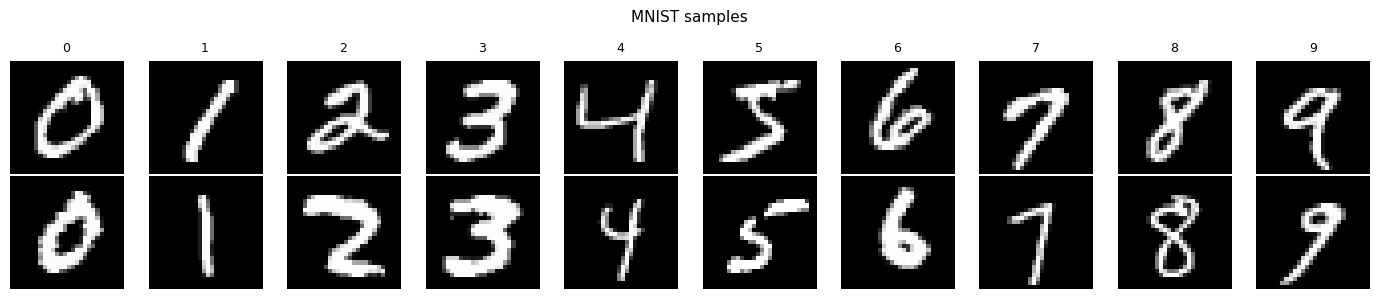

In [ ]:
# Load MNIST va chuan bi du lieu

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # 28x28 -> 784
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

X_train = train_data.data.numpy().reshape(-1, 784).astype(float) / 255.0
X_test  = test_data.data.numpy().reshape(-1, 784).astype(float) / 255.0
y_train = train_data.targets.numpy()
y_test  = test_data.targets.numpy()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

# Hien thi vai mau
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle("MNIST samples", fontsize=11)
for d in range(10):
    idx  = np.where(y_train == d)[0][0]
    idx2 = np.where(y_train == d)[0][3]
    axes[0, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[0, d].set_title(str(d), fontsize=9)
    axes[0, d].axis('off')
    axes[1, d].imshow(X_train[idx2].reshape(28,28), cmap='gray')
    axes[1, d].axis('off')
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 4.2  Pre-training DBN: Greedy Layer-wise

Train một DBN với kiến trúc `784 → 256 → 64` trên 60.000 ảnh, sử dụng Greedy Layer-wise Pre-training. RBM₁ được train trước trên pixel thô, RBM₂ được train trên biểu diễn của RBM₁.

**Siêu tham số quan trọng:**
- `layer_sizes=[784, 256, 64]`: kiến trúc thu hẹp dần, buộc mô hình phải nén thông tin
- `epochs=30`: số lần duyệt qua dữ liệu cho mỗi RBM
- `k=1`: CD-1 (1 bước Gibbs), đủ nhanh và hiệu quả trong thực tế
- `lr=0.05`: learning rate tương đối cao vì CD không phải gradient chính xác

**Output mong đợi:** Reconstruction MSE giảm dần theo epoch cho cả hai RBM. Nếu MSE không giảm, thử tăng `lr` hoặc `epochs`.


Greedy Layer-wise Pre-training========================================
Pre-training RBM 1: 784 -> 256
  Epoch 7/30 | Reconstruction MSE: 0.015882
  Epoch 14/30 | Reconstruction MSE: 0.012824
  Epoch 21/30 | Reconstruction MSE: 0.011612
  Epoch 28/30 | Reconstruction MSE: 0.010987
  Output shape: (60000, 256)
Pre-training RBM 2: 256 -> 64
  Epoch 7/30 | Reconstruction MSE: 0.043148
  Epoch 14/30 | Reconstruction MSE: 0.037195
  Epoch 21/30 | Reconstruction MSE: 0.034795
  Epoch 28/30 | Reconstruction MSE: 0.033428
  Output shape: (60000, 64)


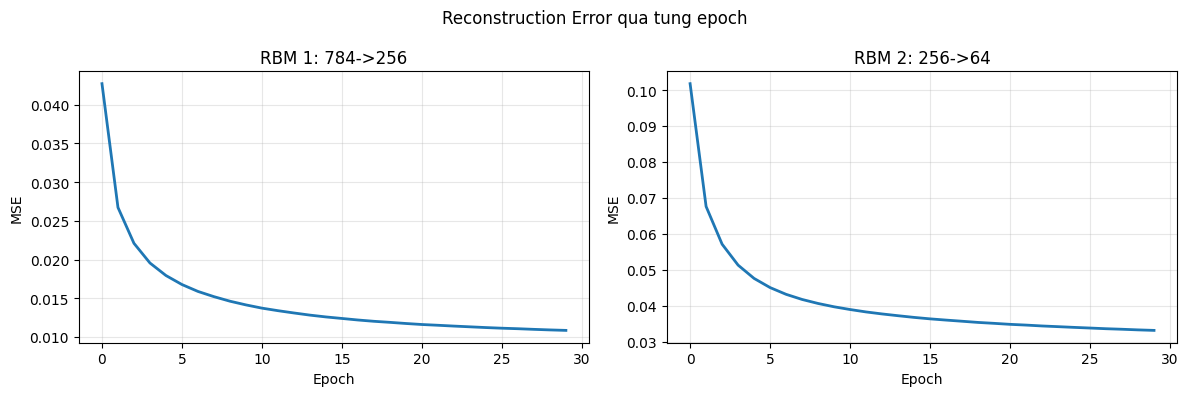

In [ ]:
# Train DBN

N = 60000
X_sub = X_train[:N]

# Kien truc: 784 -> 256 -> 64
# (nho de demo nhanh; production: 784 -> 512 -> 256 -> 128)
dbn = DBN(layer_sizes=[784, 256, 64], lr=0.05)

print("Greedy Layer-wise Pre-training" + "="*40)
errors = dbn.pretrain(X_sub, epochs=30, batch_size=128, k=1)

# Ve learning curves
fig, axes = plt.subplots(1, len(errors), figsize=(12, 4))
fig.suptitle("Reconstruction Error qua tung epoch", fontsize=12)
for ax, (idx, errs) in zip(axes, errors.items()):
    ax.plot(errs, linewidth=2)
    ax.set_title(f"RBM {idx}: {dbn.rbms[idx-1].m}->{dbn.rbms[idx-1].n}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_error.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 4.3  Kiểm tra chất lượng: Reconstruction

Chọn một ảnh mẫu cho mỗi chữ số (0-9), encode lên hidden layer cao nhất rồi decode về lại visible layer. So sánh ảnh gốc (hàng trên) với ảnh tái tạo (hàng dưới).

**Output mong đợi và cách đọc:**
- Nếu reconstruction **rõ nét**: mô hình đã học được cấu trúc dữ liệu tốt
- Nếu reconstruction **mờ hoặc nhiễu**: cần train lâu hơn hoặc điều chỉnh kiến trúc
- Ảnh tái tạo không nhất thiết phải giống hệt — mô hình đang tái tạo *ý nghĩa*, không copy từng pixel


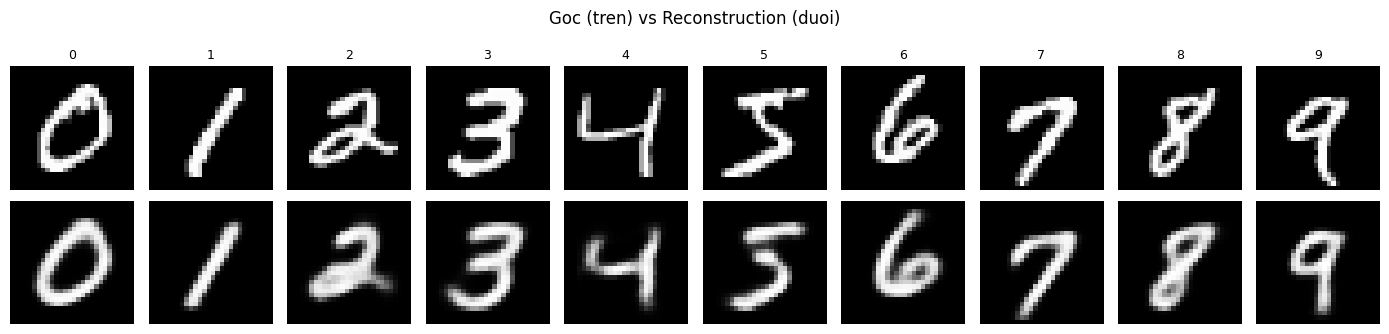

In [ ]:
# So sanh: anh goc vs reconstruction

sample_idx = [np.where(y_train == d)[0][0] for d in range(10)]
X_sample   = X_train[sample_idx]
X_recon    = dbn.reconstruct(X_sample)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.suptitle("Goc (tren) vs Reconstruction (duoi)", fontsize=12)
for i in range(10):
    axes[0, i].imshow(X_sample[i].reshape(28,28), cmap='gray')
    axes[0, i].set_title(str(i), fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_recon[i].reshape(28,28), cmap='gray')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('reconstruction.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 3.1  Generative: Sinh ảnh từ nhiễu

Đây là phần làm rõ sự khác biệt căn bản giữa DBN và các mạng phân loại thông thường.

Khi ta chạy đoạn code dưới đây, không có ảnh nào từ tập train được đưa vào. Mô hình bắt đầu từ một vector hoàn toàn ngẫu nhiên ở hidden layer cao nhất — 64 giá trị được lấy mẫu từ phân phối đồng đều. Sau đó, Gibbs Sampling chạy nhiều bước: mô hình liên tục đi lên và đi xuống giữa hidden và visible layer ở tầng trên cùng, dần dần "quyết định" trạng thái của hidden layer. Trạng thái này sau đó được decode ngược xuống visible layer qua từng tầng RBM.

Kết quả là những hình ảnh được "tưởng tượng" từ phân phối mà mô hình đã học. Chúng trông như chữ số vì mô hình đã học rằng không gian vector 784 chiều không phải là một mớ hỗn độn — nó có cấu trúc, và cấu trúc đó trông như các chữ số viết tay.


**Output mong đợi:** 20 ảnh trông giống chữ số nhưng không phải ảnh nào trong tập train. Chúng có thể hơi mờ hoặc không hoàn hảo, đó là bình thường với mô hình đơn giản. Điều quan trọng là chúng có *cấu trúc* chữ số, không phải nhiễu trắng.

> CNN thông thường không có cơ chế này. Để CNN sinh ảnh, ta phải thiết kế lại toàn bộ kiến trúc (GAN, VAE). DBN có thể làm điều này tự nhiên vì bản chất của nó là mô hình xác suất trên dữ liệu.


Sinh anh tu nhieu ngau nhien (Gibbs Sampling)...


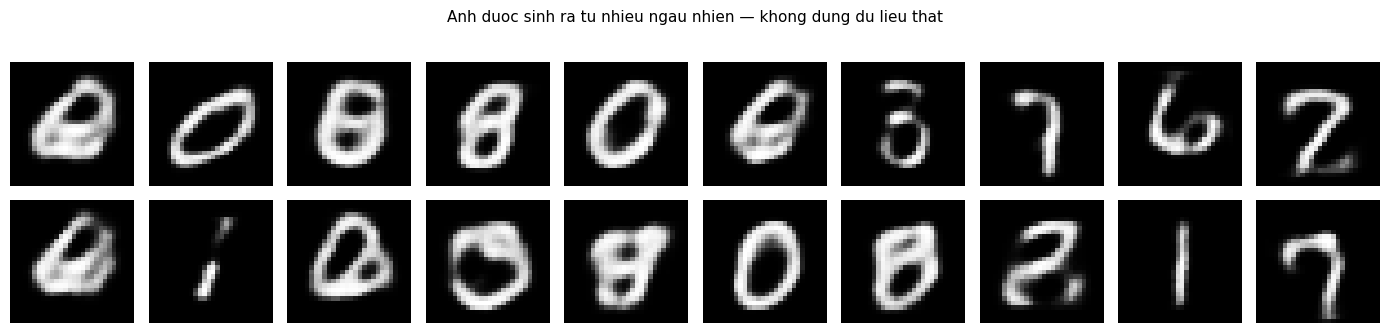

In [ ]:
# Sinh anh tu nhieu ngau nhien

print("Sinh anh tu nhieu ngau nhien (Gibbs Sampling)...")
generated = dbn.generate(n_samples=20, n_gibbs=300)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.suptitle("Anh duoc sinh ra tu nhieu ngau nhien — khong dung du lieu that", fontsize=11)
for i in range(20):
    r, c = i // 10, i % 10
    axes[r, c].imshow(generated[i].reshape(28,28), cmap='gray')
    axes[r, c].axis('off')
plt.tight_layout()
plt.savefig('generated.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 4.4  Fine-tuning

**Ta đang:** So sánh hai mô hình:
- **Có pre-training**: dùng trọng số từ DBN vừa train, thêm lớp Softmax, fine-tune với nhãn
- **Không có pre-training**: khởi tạo trọng số ngẫu nhiên, train trực tiếp với nhãn

Cả hai dùng cùng kiến trúc, cùng lượng data nhãn, chỉ khác ở điểm khởi đầu.

**Output mong đợi:** Mô hình có pre-training đạt accuracy cao hơn, đặc biệt ở những epoch đầu — nó bắt đầu từ vùng không gian tham số đã "hiểu" dữ liệu. Khoảng cách giữa hai đường sẽ rõ nhất khi lượng nhãn hạn chế.


Fine-tuning (co pre-training):
  Epoch 2/10 | Test Acc: 91.65%
  Epoch 4/10 | Test Acc: 94.15%
  Epoch 6/10 | Test Acc: 95.30%
  Epoch 8/10 | Test Acc: 96.05%
  Epoch 10/10 | Test Acc: 96.60%
Train tu dau (khong pre-training):
  Epoch 2/10 | Test Acc: 89.50%
  Epoch 4/10 | Test Acc: 92.80%
  Epoch 6/10 | Test Acc: 95.00%
  Epoch 8/10 | Test Acc: 95.90%
  Epoch 10/10 | Test Acc: 96.25%


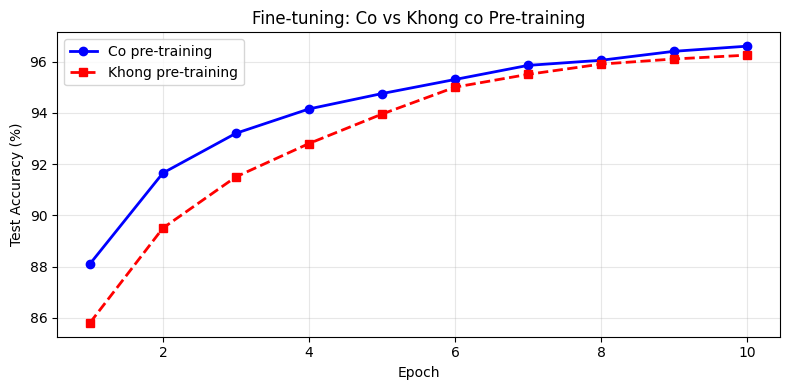

Ket qua cuoi: Pre-trained = 96.60% | From scratch = 96.25%


In [ ]:
# Fine-tuning voi PyTorch va so sanh co/khong co pre-training

class DBNClassifier(nn.Module):
    def __init__(self, dbn_obj):
        super().__init__()
        layers = []
        for rbm in dbn_obj.rbms:
            lin = nn.Linear(rbm.m, rbm.n)
            lin.weight.data = torch.FloatTensor(rbm.W.T)
            lin.bias.data   = torch.FloatTensor(rbm.c)
            layers += [lin, nn.Sigmoid()]
        self.features    = nn.Sequential(*layers)
        self.classifier  = nn.Linear(dbn_obj.layer_sizes[-1], 10)

    def forward(self, x):
        return self.classifier(self.features(x))

def train_and_eval(model, X_tr, y_tr, X_te, y_te, epochs=10, lr=1e-3):
    opt  = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xtr  = torch.FloatTensor(X_tr)
    Ytr  = torch.LongTensor(y_tr)
    hist = []
    for ep in range(epochs):
        model.train()
        for i in range(0, len(Xtr), 256):
            xb, yb = Xtr[i:i+256], Ytr[i:i+256]
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            acc = (model(torch.FloatTensor(X_te)).argmax(1) == torch.LongTensor(y_te)).float().mean().item()
        hist.append(acc * 100)
        if (ep+1) % 2 == 0:
            print(f"  Epoch {ep+1}/{epochs} | Test Acc: {acc*100:.2f}%")
    return hist

model_pre = DBNClassifier(dbn)
model_rnd = DBNClassifier(DBN([784, 256, 64]))  # khoi tao ngau nhien, khong pre-train

print("Fine-tuning (co pre-training):")
h_pre = train_and_eval(model_pre, X_train[:N], y_train[:N], X_test[:2000], y_test[:2000])

print("Train tu dau (khong pre-training):")
h_rnd = train_and_eval(model_rnd, X_train[:N], y_train[:N], X_test[:2000], y_test[:2000])

# So sanh
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 11), h_pre, 'b-o', label='Co pre-training', linewidth=2)
ax.plot(range(1, 11), h_rnd, 'r--s', label='Khong pre-training', linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Fine-tuning: Co vs Khong co Pre-training")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('finetune_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Ket qua cuoi: Pre-trained = {h_pre[-1]:.2f}% | From scratch = {h_rnd[-1]:.2f}%")


**Đọc biểu đồ:** Đường xanh (có pre-training) thường bắt đầu cao hơn và hội tụ nhanh hơn đường đỏ. Nếu khoảng cách nhỏ — có thể thử giảm `N` (lượng data nhãn dùng để train) để thấy rõ hơn lợi thế của unsupervised pre-training khi data có nhãn khan hiếm.


# Phần 5: So sánh DBN và CNN

---

DBN và CNN đều là các mạng học sâu, đều học biểu diễn phân tầng, và đều đạt kết quả ấn tượng. Nhưng chúng được xây dựng trên hai quan điểm triết học hoàn toàn khác về cách máy tính nên hiểu dữ liệu. Để so sánh công bằng, ta cần hiểu từng kiến trúc đang "nghĩ" gì khi nhìn vào một tấm ảnh.

---

## 4.1  Cách nhìn nhận không gian: Toàn cục vs Cục bộ

Khi DBN nhìn vào một tấm ảnh 28×28, điều đầu tiên nó làm là **xóa sạch mọi thông tin về vị trí không gian**. Ảnh được trải phẳng thành vector 784 chiều — pixel ở góc trái trên và pixel ở trung tâm hoàn toàn ngang hàng nhau trong mắt mô hình. Mỗi hidden neuron có thể kết nối với **bất kỳ pixel nào** trong số 784 pixel, bất kể chúng ở đâu trên ảnh. Kết quả là DBN học các **mẫu thống kê toàn cục**: "khi pixel 1 sáng và pixel 784 tối thì hidden neuron này thường bật lên" — bất kể hai pixel đó ở góc đối diện của ảnh.

CNN tiếp cận hoàn toàn khác. Nó không hỏi "pixel nào kết hợp với pixel nào?". Nó hỏi "mẫu nào xuất hiện ở vùng này của ảnh?". Mỗi neuron trong CNN chỉ "nhìn" một vùng nhỏ của ảnh — thường là 3×3 hoặc 5×5 pixel — gọi là **receptive field**. Bộ lọc (filter) 3×3 này được áp dụng lặp đi lặp lại tại mọi vị trí trên ảnh — gọi là **weight sharing**. Nghĩa là bộ lọc phát hiện "cạnh dọc" sẽ tìm cạnh dọc ở góc trái, ở trung tâm, ở góc phải — **cùng một bộ tham số**.

Hệ quả trực tiếp của sự khác biệt này là về số tham số. DBN với kiến trúc 784→512 cần $784 \times 512 = 401.408$ tham số chỉ cho lớp đầu tiên. CNN với filter 3×3 và 32 kênh chỉ cần $3 \times 3 \times 32 = 288$ tham số — nhưng filter đó được dùng chung cho toàn bộ ảnh. Đây là lý do CNN có thể huấn luyện hiệu quả hơn nhiều khi dữ liệu có cấu trúc không gian.

<img src="https://www.researchgate.net/profile/Jiayan-Qiu/publication/303897528/figure/fig1/AS:371773297184768@1465649069338/Comparison-between-convolutional-layers-with-weights-sharing-and-fully-connected-It-can.png" width="600">
<img src="https://maurice-weiler.gitlab.io/blog_post/cnn-book_2_conventional_cnns/images/weight_sharing_MLP_to_CNN_hubfef8b7c633da54dc0d7c6393672b571_504206_1320x0_resize_q80_h2_lanczos_3.webp" width="600">

Mạng nơ-ron tích chập (CNN) là kiến ​​trúc mạng tiêu chuẩn cho các tín hiệu có cấu trúc không gian, chẳng hạn như hình ảnh, âm thanh, video hoặc trường tensor trong khoa học vật lý. Chúng khác với các mạng kết nối đầy đủ thông thường ở hai khía cạnh:

1. Chúng thường có kết nối nơron cục bộ .
2. Chúng chia sẻ trọng số (convolution kernel) giữa các vị trí không gian khác nhau.

---

## 4.2  Cách trích xuất đặc trưng: Học thống kê vs Học bộ lọc không gian

DBN học đặc trưng bằng cách tìm **các mẫu thống kê** trong dữ liệu. Hidden neuron trong RBM học để bật lên khi một nhóm visible neuron có trạng thái đặc trưng nhất định — một loại "từ điển" các mẫu hay xuất hiện cùng nhau trong dữ liệu. Không có giả định nào về không gian, thứ tự, hay cấu trúc cục bộ. Đây là lợi thế khi dữ liệu không có cấu trúc không gian tự nhiên.

CNN học đặc trưng bằng cách học các **bộ lọc không gian** (spatial filters). Ở tầng đầu, các filter học cách phát hiện cạnh, góc, gradient màu sắc — những đặc trưng cơ bản của ảnh. Ở tầng sâu hơn, các filter học cách phát hiện textures, patterns, rồi đến các cấu trúc phức tạp hơn. Toàn bộ quá trình khai thác triệt để thực tế rằng **pixel gần nhau trong ảnh có quan hệ mạnh hơn pixel xa nhau**. Đây là prior knowledge về cấu trúc dữ liệu hình ảnh được tích hợp vào kiến trúc mô hình.

---

## 4.3  Generative vs Discriminative

Đây là điểm khác biệt quan trọng nhất, và cũng là điều dễ bị hiểu nhầm nhất.

**CNN là discriminative model**. Nó học hàm $P(y \mid \mathbf{x})$ — xác suất nhãn $y$ khi đã biết dữ liệu $\mathbf{x}$. Toàn bộ sức mạnh của CNN tập trung vào việc vẽ ra **ranh giới quyết định** (decision boundary) phân tách các lớp. CNN biết rất rõ "đây là mèo hay chó" nhưng không có khái niệm gì về "con mèo trông như thế nào nếu tôi phải vẽ một con từ đầu".

**DBN là generative model**. Nó học hàm $P(\mathbf{x})$ — xác suất của bản thân dữ liệu. Mô hình phải hiểu toàn bộ phân phối của dữ liệu: pixel nào hay xuất hiện cùng nhau, cấu trúc nào là "hợp lệ" trong không gian dữ liệu. Từ $P(\mathbf{x})$ này, ta có thể làm nhiều thứ: phân loại (tính $P(\mathbf{x}|y)$ cho từng lớp và so sánh), sinh dữ liệu mới (lấy mẫu từ $P(\mathbf{x})$), phát hiện bất thường (nếu $P(\mathbf{x})$ thấp thì dữ liệu này "lạ").

Một cách hiểu khác: CNN học cách **phân biệt**, DBN học cách **hiểu**. Sự khác biệt này không phải về cái nào tốt hơn — mà về cái nào phù hợp với bài toán nào.

---

## 4.4  Ai phù hợp với bài toán nào?

Khi DBN có lợi thế:

Bài toán đầu tiên mà DBN vượt trội là khi **dữ liệu nhãn khan hiếm**. Pre-training unsupervised có thể tận dụng hàng triệu dữ liệu không nhãn — điều mà CNN thuần túy không thể làm hiệu quả. Đây là lý do DBN được nghiên cứu nhiều trong y sinh học, nơi nhãn cần chuyên gia gán tay và rất tốn kém.

Bài toán thứ hai là khi **dữ liệu không có cấu trúc không gian**. Âm thanh, dữ liệu gen, dữ liệu tài chính, bảng điều tra y tế — những thứ mà khái niệm "pixel gần nhau" không có ý nghĩa. CNN không có cách nào khai thác cấu trúc không gian vốn không tồn tại. DBN — vốn dĩ xem tất cả đặc trưng ngang hàng — phù hợp tự nhiên hơn.

Bài toán thứ ba là **sinh dữ liệu mới**. Mô hình generative là yêu cầu bắt buộc. Dùng CNN để sinh ảnh là không tự nhiên — ta phải thêm nhiều thứ vào kiến trúc, kết quả là GAN hay VAE — còn DBN về bản chất đã có thể làm điều này.

Khi CNN có lợi thế:

Với bài toán **phân loại ảnh**, CNN đã chứng minh vượt trội rõ ràng kể từ AlexNet (2012). Weight sharing + local receptive field tạo ra một inductive bias cực kỳ phù hợp: đặc trưng ở góc này của ảnh nên tương tự đặc trưng cùng loại ở góc khác. DBN phải dùng nhiều tham số hơn nhiều để đạt cùng kết quả.

Khi **dữ liệu nhãn phong phú** (hàng triệu ảnh có nhãn như ImageNet), discriminative training trực tiếp bằng Backpropagation hiệu quả hơn nhiều. Lợi thế của unsupervised pre-training giảm đáng kể khi có đủ nhãn.

**Tốc độ inference** là một thực tế quan trọng: convolution được tối ưu hóa phần cứng cực tốt trên GPU — GPU về cơ bản là một cỗ máy được thiết kế để làm convolution. DBN với fully connected layers tốn nhiều memory bandwidth hơn.

---

## 4.5  Vị trí của DBN trong lịch sử Deep Learning

DBN không bị "đánh bại" bởi CNN — chúng phục vụ các mục đích khác nhau. Nhưng trong thực tế, kể từ 2012, khi ImageNet Challenge chứng minh CNN vượt trội hoàn toàn cho bài toán thị giác máy tính, và khi dữ liệu nhãn ngày càng trở nên phong phú hơn, DBN dần ít được dùng làm mô hình chính.

Tuy nhiên, **tư tưởng** của DBN vẫn sống và phát triển trong nhiều mô hình hiện đại. Variational Autoencoder (VAE) kế thừa ý tưởng học biểu diễn generative nhưng dùng reparameterization trick để train end-to-end. Diffusion Models — nền tảng của Stable Diffusion và DALL-E — học cách đảo ngược quá trình thêm nhiễu vào dữ liệu, về bản chất là học $P(\mathbf{x})$ theo một cách khác. Và toàn bộ phong trào self-supervised learning (BERT, GPT, CLIP) đang áp dụng chính triết lý của Hinton: học từ dữ liệu không nhãn trước, fine-tune với nhãn sau.

Bài báo 2006 của Hinton không chỉ giới thiệu DBN. Nó chứng minh rằng **học sâu là khả thi** — và khai sinh kỷ nguyên mà chúng ta đang sống trong đó.


---

## 5.6  Bảng tóm tắt: DBN vs CNN

Sau khi đọc qua 5 chiều so sánh, đây là bảng tổng hợp để dễ tra cứu và nhớ:

| Chiều so sánh | DBN | CNN |
|---------------|-----|-----|
| **Xử lý không gian** | Toàn cục — flatten ảnh thành vector, không quan tâm vị trí pixel | Cục bộ — receptive field, weight sharing, khai thác cấu trúc không gian |
| **Trích xuất đặc trưng** | Mẫu thống kê: học co-activation của pixel bất kỳ | Bộ lọc không gian: cạnh → texture → hình dạng phức tạp |
| **Loại mô hình** | **Generative** — học $P(\mathbf{x})$, có thể sinh dữ liệu mới | **Discriminative** — học $P(y \mid \mathbf{x})$, chỉ phân loại |
| **Phương pháp học** | Unsupervised pre-training + fine-tuning | Supervised end-to-end backpropagation |
| **Số tham số** | Nhiều (fully connected) — $784 \times 512 = 401K$ lớp đầu | Ít hơn nhiều — filter $3 \times 3 = 9$ tham số, dùng chung |
| **Sức mạnh** | Dữ liệu nhãn khan hiếm, dữ liệu phi cấu trúc không gian, sinh dữ liệu | Nhận dạng ảnh, dữ liệu có cấu trúc không gian, classification |
| **Điểm yếu** | Chậm hơn CNN trên ảnh, kém hiệu quả khi có nhiều nhãn | Không thể sinh dữ liệu tự nhiên, cần nhãn, kém với dữ liệu phi không gian |
| **Tốc độ inference** | Chậm hơn (fully connected, nhiều tham số) | Nhanh (convolution tối ưu hóa GPU cực tốt) |
| **Ứng dụng tiêu biểu** | Y sinh học, dữ liệu gen, âm thanh, semi-supervised learning | Phân loại ảnh, phát hiện đối tượng, nhận dạng khuôn mặt |


```
Dữ liệu là ảnh/video VÀ có đủ nhãn?
    → CNN

Dữ liệu không có cấu trúc không gian (âm thanh, gen, tài chính)?
    → DBN / các mô hình fully-connected

Nhãn khan hiếm, có nhiều dữ liệu không nhãn?
    → DBN pre-training + fine-tune / self-supervised learning

Cần sinh dữ liệu mới?
    → DBN (đơn giản) / VAE, GAN, Diffusion (hiện đại)
```


# Phần 6: Tổng kết

---

RBM là mô hình năng lượng, nó định nghĩa một hàm cho biết trạng thái nào của dữ liệu là "tự nhiên" và trạng thái nào là "bất thường". Vì cấu trúc bipartite không có kết nối trong cùng tầng, ta có thể tính xác suất có điều kiện song song, và Contrastive Divergence cho phép train mô hình này mà không cần tính hàm partition không thể tính được. DBN xếp chồng nhiều RBM, mỗi tầng học biểu diễn trừu tượng hơn, và Greedy Layer-wise Pre-training giải quyết vanishing gradient bằng cách đơn giản là không để gradient phải đi xa. Kết quả là một mô hình vừa hiểu cấu trúc dữ liệu đủ tốt để tái tạo nó, vừa có thể tưởng tượng ra dữ liệu mới chưa từng thấy.

Nếu muốn đi sâu hơn từ nền tảng này, ba hướng tự nhiên nhất là:

**Variational Autoencoder (VAE)** là bước tiến hóa trực tiếp của DBN: thay vì binary hidden units, VAE dùng latent space liên tục và train end-to-end bằng variational inference. Kết quả là latent space có thể interpolate được, ta có thể "trộn" hai chữ số và xem trung gian giữa chúng trông như thế nào.

**Generative Adversarial Network (GAN)** tiếp cận bài toán generative hoàn toàn khác: thay vì học $P(\mathbf{x})$ trực tiếp, GAN train hai mạng cạnh tranh nhau, generator cố sinh ảnh thật, discriminator cố phân biệt ảnh thật và ảnh giả. Kết quả là những ảnh sinh ra chất lượng cao hơn nhiều, nhưng training không ổn định hơn nhiều.

**Self-supervised Learning** (BERT, GPT, CLIP, MAE) là đại diện của triết lý Hinton: học từ dữ liệu không nhãn trước. Thay vì dùng reconstruction như DBN, các mô hình này dùng các pretext task — đoán từ bị che, đoán thứ tự, đối chiếu ảnh và caption — để học biểu diễn phong phú mà không cần nhãn.
